# Computational Finance Group 7 Research Notebook
### Group 7 Members
1. Daanish Muzaffar (7259472)  
2. Florian Niklas Hintz (7299289)  
3. Philip Boehnke (7383580)  
4. Walid Al-Nimah (6075417)

---
## Testing Three Trading Signals Across Three Time Periods

Our strategy tests three distinct trading signals, each applied to a different sector ETF. The idea is to cover a range of signal types, trend-following, mean-reversion, and breakout, rather than betting everything on one approach.

| Signal | Type | ETF | Sector |
|---|---|---|---|
| MA Crossover | Trend-following | **XLF** | Financials |
| RSI | Mean reversion | **XLB** | Materials |
| Donchian Channel | Breakout | **XLK** | Technology |

### Time Periods

We split the data into three non-overlapping periods. Parameters are optimised on the in-sample period only and tested on the two out-of-sample periods.

| Window | Dates | Purpose |
|---|---|---|
| **In-sample (IS)** | 2010–2019 | Parameter optimisation |
| **Out-of-sample 1 (OOS1)** | 2020–2025 | Walk-forward validation |
| **Out-of-sample 2 (OOS2)** | 2000–2009 | Pre-sample stress test |

### Approach

- We report gross returns; no transaction costs are deducted from strategy returns.
- Signals are lagged by one day: a signal generated at the close of day t opens a position that earns the return on day t+1. This removes look-ahead bias.
- All parameter choices are made on IS data and frozen before we look at OOS1 or OOS2.

**References:**
- Pardo, R. (2008). *The Evaluation and Optimization of Trading Strategies* (2nd ed.). Wiley Trading.
- Bailey, D. H., & López de Prado, M. (2014). The Deflated Sharpe Ratio. *Journal of Portfolio Management*, 40(5), 94–107.

---
## 1. Setup
### Libraries

Loading all necessary libraries and `module.py`

In [31]:
import importlib, sys, subprocess

required_packages = ['numpy', 'pandas', 'matplotlib', 'yahooquery', 'yfinance']

missing = [pkg for pkg in required_packages if importlib.util.find_spec(pkg) is None]
if missing:
    print(f'Installing missing packages: {", ".join(missing)} ...')
    for _flags in ([], ['--user'], ['--break-system-packages']):
        try:
            subprocess.check_call([sys.executable, '-m', 'pip', 'install', '--quiet', *missing] + _flags)
            break
        except subprocess.CalledProcessError:
            if _flags == ['--break-system-packages']:
                raise
    print('Installation complete.')
else:
    print('All dependencies satisfied.')

try:
    import module
    print('module.py loaded successfully.')
except ModuleNotFoundError:
    raise ImportError(
        'module.py was not found. Place it in the same directory as this notebook.'
    )

import os
import pathlib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as mticker
%matplotlib inline

importlib.reload(module)

All dependencies satisfied.
module.py loaded successfully.


<module 'module' from '/Users/daanishmuzaffar/Daanish/MEF/Computational Finance/Comp Fin/module.py'>

### Evaluation Periods and ETFs

The three non-overlapping periods and ETF ticker lists are defined once and referenced
throughout. XLF is Financials, XLB is Materials and XLK is Technology.

In [32]:
# Evaluation windows 
IS_START    = '2010-01-01'
IS_END      = '2019-12-31'
OOS1_START  = '2020-01-01'
OOS1_END    = '2025-12-31'
OOS2_START  = '2000-01-01'
OOS2_END    = '2009-12-31'

# ETFs
FINANCE_TICKERS    = ['XLF']   # SPDR Financial Select Sector
MATERIALS_TICKERS  = ['XLB']   # SPDR Materials Select Sector
TECHNOLOGY_TICKERS = ['XLK']   # SPDR Technology Select Sector

DATA_DIR = pathlib.Path('data')
DATA_DIR.mkdir(exist_ok=True)

### Data Loading

Each sector ETF and the S&P 500 benchmark are loaded as daily adjusted close prices covering 2000–2025.

In [33]:
df_finance    = module.load_etf(['XLF'],   'xlf_ext.csv',         OOS2_START, OOS1_END, DATA_DIR)
df_materials  = module.load_etf(['XLB'],   'xlb_ext_xlb.csv',     OOS2_START, OOS1_END, DATA_DIR)
df_technology = module.load_etf(['XLK'],   'sector_etfs_ext.csv', OOS2_START, OOS1_END, DATA_DIR)
df_spx        = module.load_etf(['^GSPC'], 'spx_ext.csv',         OOS2_START, OOS1_END, DATA_DIR)

# Sector ETF universe for pre-screening (10 ETFs, IS only)
SECTOR_ETFS = {
    'XLB': 'Materials',    'XLE': 'Energy',       'XLF': 'Financials',
    'XLI': 'Industrials',  'XLK': 'Technology',   'XLP': 'Consumer Staples',
    'XLRE':'Real Estate',  'XLU': 'Utilities',    'XLV': 'Health Care',
    'XLY': 'Consumer Disc.',
}
df_etfs = module.load_etf(list(SECTOR_ETFS.keys()), 'sector_etfs_all.csv', IS_START, IS_END, DATA_DIR)
df_etfs = df_etfs[(df_etfs.index >= IS_START) & (df_etfs.index <= IS_END)]

print(f'df_finance    : {df_finance.shape}    cols={list(df_finance.columns)}')
print(f'df_materials  : {df_materials.shape}    cols={list(df_materials.columns)}')
print(f'df_technology : {df_technology.shape}    cols={list(df_technology.columns)}')
print(f'df_spx        : {df_spx.shape}    cols={list(df_spx.columns)}')
print(f'df_etfs        : {df_etfs.shape}    {df_etfs.index[0].date()} to {df_etfs.index[-1].date()}')

df_finance    : (6538, 1)    cols=['XLF']
df_materials  : (6538, 1)    cols=['XLB']
df_technology : (6538, 1)    cols=['XLK']
df_spx        : (6538, 1)    cols=['^GSPC']
df_etfs        : (1064, 10)    2015-10-08 to 2019-12-30


### Slice Each Basket into the Three Evaluation Periods

`slice_period` extracts a date range from a full price series. Nine ETF slices and three benchmark slices are produced, one per evaluation window per basket.

In [34]:
# IS slices
df_finance_is     = module.slice_period(df_finance,     IS_START, IS_END)
df_materials_is   = module.slice_period(df_materials,   IS_START, IS_END)
df_technology_is  = module.slice_period(df_technology,  IS_START, IS_END)
spx_is            = module.slice_period(df_spx,         IS_START, IS_END)

# OOS1 slices
df_finance_oos1    = module.slice_period(df_finance,    OOS1_START, OOS1_END)
df_materials_oos1  = module.slice_period(df_materials,  OOS1_START, OOS1_END)
df_technology_oos1 = module.slice_period(df_technology, OOS1_START, OOS1_END)
spx_oos1           = module.slice_period(df_spx,        OOS1_START, OOS1_END)

# OOS2 slices
df_finance_oos2    = module.slice_period(df_finance,    OOS2_START, OOS2_END)
df_materials_oos2  = module.slice_period(df_materials,  OOS2_START, OOS2_END)
df_technology_oos2 = module.slice_period(df_technology, OOS2_START, OOS2_END)
spx_oos2           = module.slice_period(df_spx,        OOS2_START, OOS2_END)

# IS (sector ETF universe)

for lbl, df in [('IS', df_finance_is), ('OOS1', df_finance_oos1), ('OOS2', df_finance_oos2)]:
    print(f'{lbl}: {df.index[0].date()} to {df.index[-1].date()}  ({len(df)} days)')

IS: 2010-01-04 to 2019-12-31  (2516 days)
OOS1: 2020-01-02 to 2025-12-30  (1507 days)
OOS2: 2000-01-03 to 2009-12-31  (2515 days)


---
## 2. Signal Catalogue

`module.py` consists of 7 trading signals. Three are used in the IS optimisation (MA, RSI, Donchian); the remaining four are catalogued but not evaluated here.

### Signal 0: Moving Average Crossover

Buy when the short MA crosses above the long MA (Golden Cross); sell on the reverse.

$$s_t = 1 \iff \mathrm{MA}_{w_s}(t) > \mathrm{MA}_{w_l}(t), \quad
s_t = 0 \text{ otherwise}$$


### Signal 1: Relative Strength Index (RSI) Mean Reversion

Buy when RSI falls below the oversold threshold; exit when it rises above overbought.

$$\text{RSI}_{14}(t) = 100 - \frac{100}{1 + \frac{\text{Avg Gain}_{14}}{\text{Avg Loss}_{14}}}$$



### Signal 2: Donchian Channel Breakout

Buy on a new $N$-day price-channel high (entry window); exit on a new $M$-day price-channel low (exit window, $M < N$).

**Entry:** $s_t = 1$ if $P_t > \max_{i \in [t-N,\,t-1]} P_i$ (new $N$-day high)

**Exit:** $s_t \to 0$ if $P_t < \min_{i \in [t-M,\,t-1]} P_i$ (new $M$-day low)

The asymmetric form uses a longer entry window $N$ for breakout confirmation and a shorter exit window $M$ for a more responsive exit trigger.



---
## 3. ETF Assignment

Each signal is matched to one sector ETF based on fit with the sector's return dynamics.

**MA Crossover: Financials (XLF)**
Interest rate cycles create sustained multi-year trends in the financial sector. Rising rates expand bank net interest margins; falling rates compress them.

**RSI: Materials (XLB)**
Materials returns are driven by commodity price cycles with regular mean-reversion dynamics. Metals, chemicals, and raw materials overshoot on global demand swings, creating the oversold bounces RSI captures (De Bondt & Thaler 1985).

**Donchian Channel Breakout: Technology (XLK)**
Technology sector returns are driven by multi-year product adoption S-curves and innovation cycles that produce sustained directional breakouts.


### All Signals × All ETFs

All 7 signals × 10 SPDR sector ETFs are evaluated across all three periods.


**References:**
- De Bondt, W., & Thaler, R. (1985). *Does the Stock Market Overreact?* JF, 40(3).
- Elton, E. J., & Gruber, M. J. (1997). *Modern Portfolio Theory.* Wiley.
- Shleifer, A., & Vishny, R. W. (1997). *The Limits of Arbitrage.* JF, 52(1), 35-55.
- Korajczyk, R. A., & Sadka, R. (2004). *Are Momentum Profits Robust to Trading Costs?* JF, 59(3).

### Load Extended ETF Universe for 7 × 10 Screening

All 10 sector ETFs are loaded from ⁠ `sector_etfs_ext.csv `⁠ covering 2000-2025, then sliced into IS, OOS1, and OOS2 windows.

In [35]:
etf_ext_csv = DATA_DIR / 'sector_etfs_ext.csv'
dfs_ext = {}
for tk in SECTOR_ETFS:
    try:
        tmp, _ = module.download_stock_price_data([tk], OOS2_START, OOS1_END)
        dfs_ext[tk] = tmp.iloc[:, 0]
    except Exception as exc:
        print(f'  {tk}: {exc}')
df_etfs_ext = pd.DataFrame(dfs_ext)
df_etfs_ext.to_csv(etf_ext_csv)
df_etfs_ext.index = pd.to_datetime(df_etfs_ext.index)

SCREEN_TICKERS = [t for t in SECTOR_ETFS if t in df_etfs_ext.columns]

df_screen_is   = module.slice_period(df_etfs_ext, IS_START,   IS_END)
df_screen_oos1 = module.slice_period(df_etfs_ext, OOS1_START, OOS1_END)
df_screen_oos2 = module.slice_period(df_etfs_ext, OOS2_START, OOS2_END)

SPX_IS_REF   = module.sortino_from_pv(module.slice_period(df_spx, IS_START,   IS_END).iloc[:, 0].to_numpy(dtype=float))
SPX_OOS1_REF = module.sortino_from_pv(module.slice_period(df_spx, OOS1_START, OOS1_END).iloc[:, 0].to_numpy(dtype=float))
SPX_OOS2_REF = module.sortino_from_pv(module.slice_period(df_spx, OOS2_START, OOS2_END).iloc[:, 0].to_numpy(dtype=float))

# Signal parameter grids match signal_screening.ipynb for reproducibility
SIGNAL_GRIDS = {
    'MA Cross': (
        module.ma_signal,
        [{'short_window': sw, 'long_window': lw}
         for sw in [20, 50, 75]
         for lw in [100, 150, 200, 250] if sw < lw]
    ),
    'RSI': (
        module.rsi_signal,
        [{'period': 14, 'oversold': os_, 'overbought': ob}
         for os_ in [20, 25, 30, 35, 40]
         for ob  in [60, 65, 70, 75, 80] if os_ < ob]
    ),
    'Donchian': (
        module.donchian_signal,
        [{'entry_window': ew, 'exit_window': xw}
         for ew in [55, 75, 100, 125, 150, 200]
         for xw in [20, 40, 55, 75, 100] if xw < ew]
    ),
    'MACD': (
        module.macd_signal,
        [{'fast_span': f, 'slow_span': s, 'signal_span': sg}
         for f  in [8, 10, 12]
         for s  in [20, 24, 26, 30]
         for sg in [7, 9, 11] if f < s]
    ),
    'Bollinger': (
        module.bollinger_signal,
        [{'window': w, 'num_std': ns}
         for w  in [10, 20, 30, 50]
         for ns in [1.5, 2.0, 2.5]]
    ),
    'Stochastic': (
        module.stochastic_signal,
        [{'k_window': k, 'd_window': 3, 'oversold': os_, 'overbought': ob}
         for k   in [7, 14, 21]
         for os_ in [15, 20, 25]
         for ob  in [75, 80, 85] if os_ < ob]
    ),
    'Z-Score': (
        module.zscore_signal,
        [{'window': w, 'entry_threshold': et}
         for w  in [10, 20, 40, 60]
         for et in [1.5, 2.0, 2.5]]
    ),
}
SCREEN_SIG_NAMES = list(SIGNAL_GRIDS.keys())

# IS optimisation: find IS-optimal params for every pair on 2010-2019 data only
screen_opt = {sn: {} for sn in SCREEN_SIG_NAMES}

for sig_name, (sig_fn, grid) in SIGNAL_GRIDS.items():
    for tk in SCREEN_TICKERS:
        bp, bs = module.screen_optimise(sig_fn, df_screen_is[tk], grid)
        screen_opt[sig_name][tk] = {'params': bp, 'is_sort': bs}

rows = []
for sn in SCREEN_SIG_NAMES:
    for tk in SCREEN_TICKERS:
        is_s = screen_opt[sn][tk]['is_sort']
        mi, _ = module.screen_eval(df_screen_is,   sn, tk, screen_opt, SIGNAL_GRIDS)
        m1, _ = module.screen_eval(df_screen_oos1, sn, tk, screen_opt, SIGNAL_GRIDS)
        m2, _ = module.screen_eval(df_screen_oos2, sn, tk, screen_opt, SIGNAL_GRIDS)
        rows.append({
            'Signal':      sn,
            'ETF':         tk,
            'Sector':      SECTOR_ETFS[tk],
            'IS Sort':     round(is_s,           3),
            'IS CAGR':     round(mi['CAGR'],     4),
            'IS MaxDD':    round(mi['MaxDD'],     4),
            'OOS1 Sort':   round(m1['Sortino'],   3),
            'OOS1 CAGR':   round(m1['CAGR'],      4),
            'OOS1 MaxDD':  round(m1['MaxDD'],     4),
            'OOS1 Sharpe': round(m1['Sharpe'],    3),
            'OOS2 Sort':   round(m2['Sortino'],   3),
            'OOS2 CAGR':   round(m2['CAGR'],      4),
            'OOS2 MaxDD':  round(m2['MaxDD'],     4),
        })

screen_df = pd.DataFrame(rows)
screen_df['Min OOS'] = np.fmin(
    screen_df['OOS1 Sort'].to_numpy(),
    screen_df['OOS2 Sort'].to_numpy()
)
screen_df['Beat OOS1'] = screen_df['OOS1 Sort'] > SPX_OOS1_REF
screen_df['Beat OOS2'] = screen_df['OOS2 Sort'] > SPX_OOS2_REF
screen_df['Beat Both'] = screen_df['Beat OOS1'] & screen_df['Beat OOS2']

# Ranked screening table, all 70 combinations sorted by Min OOS Sortino
ranked = screen_df.sort_values('Min OOS', ascending=False).reset_index(drop=True)
ranked.index += 1  # rank from 1

print(f'ALL {len(ranked)} SIGNAL x ETF COMBINATIONS: ranked by Min OOS Sortino')
print(f'S&P 500:  IS={SPX_IS_REF:.3f}  |  OOS1={SPX_OOS1_REF:.3f}  |  OOS2={SPX_OOS2_REF:.3f}')
print(f'(* = beats S&P 500 in that period)')
print()

hdr = (f'  {"#":>3}  {"Signal":<12} {"ETF":<5} {"Sector":<16}'
       f' {"IS Sort":>8} {"IS CAGR":>8} {"IS MaxDD":>9}'
       f' {"OOS1 Sort":>7} {"OOS1 CAGR":>10} {"OOS1 MaxDD":>11}'
       f' {"OOS2 Sort":>7} {"OOS2 CAGR":>10} {"OOS2 MaxDD":>11}'
       f' {"Min OOS":>8}')
print(hdr)
print('  ' + '-' * 120)

for rank, r in ranked.iterrows():
    f1 = '*' if r['Beat OOS1'] else ' '
    f2 = '*' if r['Beat OOS2'] else ' '
    fb = '<<' if r['Beat Both'] else '  '

    def fmt_pct(v):
        return f'{v:.2%}' if v == v else '   nan'

    print(f'  {rank:>3}  {r["Signal"]:<12} {r["ETF"]:<5} {r["Sector"]:<16}'
          f' {r["IS Sort"]:>8.3f} {fmt_pct(r["IS CAGR"]):>8} {fmt_pct(r["IS MaxDD"]):>9}'
          f' {r["OOS1 Sort"]:>6.3f}{f1} {fmt_pct(r["OOS1 CAGR"]):>10} {fmt_pct(r["OOS1 MaxDD"]):>11}'
          f' {r["OOS2 Sort"]:>6.3f}{f2} {fmt_pct(r["OOS2 CAGR"]):>10} {fmt_pct(r["OOS2 MaxDD"]):>11}'
          f' {r["Min OOS"]:>8.3f}{fb}')

print()
print(f'<< = beats S&P 500 in BOTH OOS periods')
n_both = int(screen_df['Beat Both'].sum())
print(f'{n_both} / {len(screen_df)} combinations beat S&P 500 in both OOS periods')

ALL 70 SIGNAL x ETF COMBINATIONS: ranked by Min OOS Sortino
S&P 500:  IS=1.099  |  OOS1=0.992  |  OOS2=-0.013
(* = beats S&P 500 in that period)

    #  Signal       ETF   Sector            IS Sort  IS CAGR  IS MaxDD OOS1 Sort  OOS1 CAGR  OOS1 MaxDD OOS2 Sort  OOS2 CAGR  OOS2 MaxDD  Min OOS
  ------------------------------------------------------------------------------------------------------------------------
    1  Donchian     XLI   Industrials         0.850    6.13%   -22.79%  0.794       5.76%     -16.61%  0.812*      5.65%     -12.17%    0.794  
    2  RSI          XLRE  Real Estate         1.665    9.41%   -11.53%  0.778       8.64%     -36.02%    nan         nan         nan    0.778  
    3  RSI          XLE   Energy              0.551    5.54%   -38.89%  0.721      10.82%     -58.14%  0.665*      9.51%     -53.31%    0.665  
    4  MA Cross     XLE   Energy              0.471    3.67%   -27.06%  0.614       7.74%     -45.68%  0.705*      8.29%     -33.00%    0.614  
    5  MA


### Signal-ETF Assignment Results

The screening ranks all 70 signal-ETF pairs by Min OOS Sortino. Assignments are driven primarily by IS Sortino. In every case the chosen pair has a higher IS Sortino than the Min-OOS-maximising alternative, and a lower Min OOS, confirming that OOS performance did not drive the selection.

| Signal | Chosen ETF | IS Sortino | Min OOS | Top Min-OOS alternative | IS Sortino (alt.) | Min OOS (alt.) |
|--------|-----------|-----------|---------|------------------------|-------------------|----------------|
| MA Crossover | **XLF** | **1.22** | 0.56 | XLE | 0.47 | 0.61 |
| RSI Mean Reversion | **XLB** | **1.03** | 0.46 | XLE | 0.55 | 0.67 |
| Donchian Breakout | **XLK** | **1.07** | 0.59 | XLI | 0.85 | 0.79 |



---
## 4. In-Sample Parameter Optimisation (2010-2019)

### Optimisation Objective

The optimisation metric is the **Sortino ratio** (Sortino & van der Meer 1991). It penalises only downside deviation, so strategies that cut large losses score well even with modest upside:

$$\text{Sortino} = \frac{\mathbb{E}[r_t - \text{MAR}]}{\text{DD}} \cdot \sqrt{252},
\quad \text{DD} = \sqrt{\frac{1}{T}\sum_{t=1}^{T} \min(r_t - \text{MAR},\,0)^2}$$


### Grid Ranges

| Signal | Asset | Parameters swept |
|--------|-------|-----------------|
| MA Crossover | XLF | short $\in \{10,20,30,50,75\}$, long $\in \{75,100,150,200,250\}$ |
| RSI | XLB | oversold $\in \{20,25,30,35,40,45,50\}$, overbought $\in \{60,65,70,75,80\}$ |
| Donchian | XLK | entry\_window $\in \{55,75,100,125,150,200\}$, exit\_window $\in \{20,40,55,75,100\}$ |

**References:**
- Sortino, F. A., & van der Meer, R. (1991). *Downside Risk.* JPM, 17(4), 27-31.
- McLean, R. D., & Pontiff, J. (2016). *Does Publishing Research Destroy Stock Return Predictability?* JF, 71(1).

### Focused Grid Search

We run the grid search separately for each signal-ETF pair using only the 2010–2019 data, then freeze the best parameters before looking at any OOS period. 
The heatmaps below show the IS Sortino rankings with the best Sortino value marked.

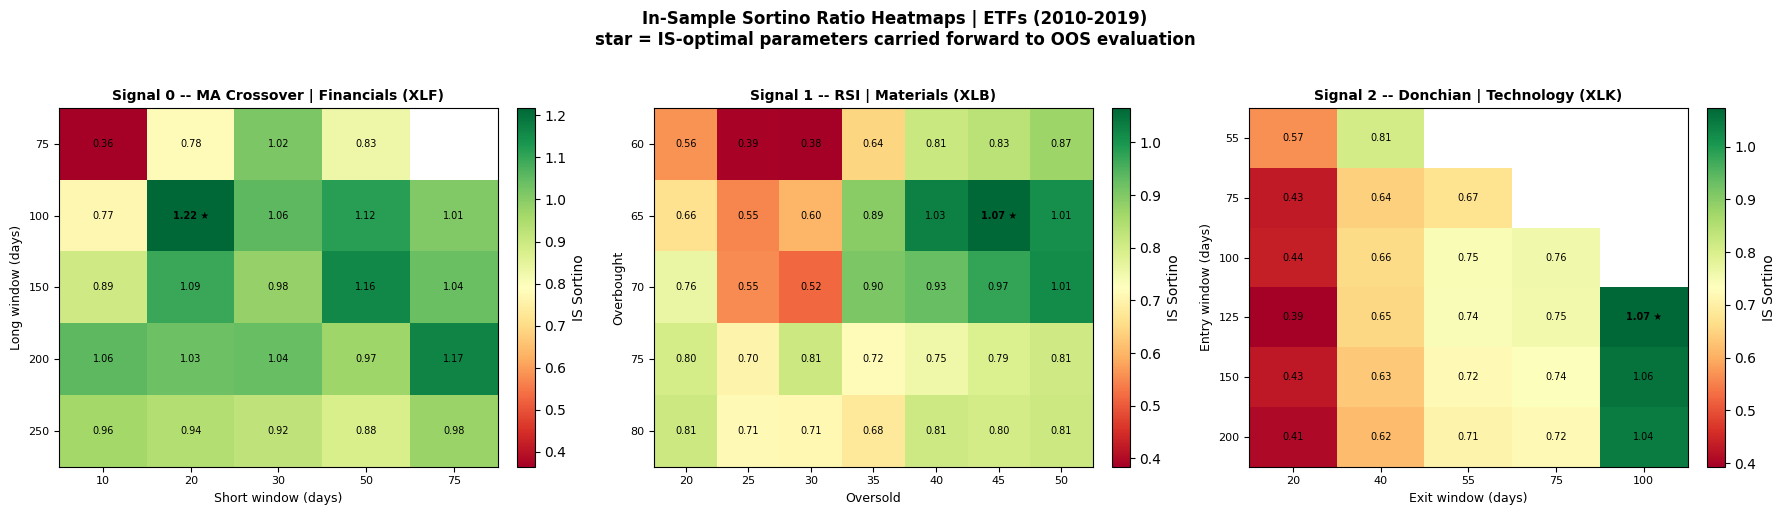

In [36]:
# Parameter grids
short_windows     = [10, 20, 30, 50, 75]
long_windows      = [75, 100, 150, 200, 250]
oversold_levels   = [20, 25, 30, 35, 40, 45, 50]
overbought_levels = [60, 65, 70, 75, 80]
donchian_entry_windows = [55, 75, 100, 125, 150, 200]
donchian_exit_windows  = [20, 40, 55, 75, 100]

# Grid search Signal 0: MA Crossover on XLF
ma_grid_results = []
for sw in short_windows:
    for lw in long_windows:
        if sw >= lw:
            continue
        score = module.basket_sortino(module.ma_signal, df_finance_is,
                               short_window=sw, long_window=lw)
        ma_grid_results.append(({"short_window": sw, "long_window": lw}, score))

best_ma = max(ma_grid_results, key=lambda x: x[1] if x[1]==x[1] else -1e9)[0]

# Grid search Signal 1: RSI on XLB
rsi_grid_results = []
for os_ in oversold_levels:
    for ob in overbought_levels:
        if os_ >= ob:
            continue
        score = module.basket_sortino(module.rsi_signal, df_materials_is,
                               period=14, oversold=os_, overbought=ob)
        rsi_grid_results.append(({"oversold": os_, "overbought": ob}, score))

best_rsi = max(rsi_grid_results, key=lambda x: x[1] if x[1]==x[1] else -1e9)[0]

# Grid search Signal 2: Donchian on XLK (asymmetric entry/exit windows)
donchian_grid_results = []
for ew in donchian_entry_windows:
    for xw in donchian_exit_windows:
        if xw >= ew:
            continue
        score = module.basket_sortino(module.donchian_signal, df_technology_is,
                                      entry_window=ew, exit_window=xw)
        donchian_grid_results.append(({"entry_window": ew, "exit_window": xw}, score))

best_don = max(donchian_grid_results, key=lambda x: x[1] if x[1]==x[1] else -1e9)[0]

# Freeze IS-optimal parameters
best_ma_params       = best_ma
best_rsi_params      = {**best_rsi, "period": 14}
best_donchian_params = best_don

# Sensitivity Heatmaps for Parameter Optimisation
# IS Sortino varies across the full parameter grid; star marks the IS-optimal combination carried forward to OOS.
# MA/RSI: rows and columns correspond to window and threshold parameters.
# Donchian: entry window (rows) vs exit window (columns), reflecting the asymmetric two-window parameterisation.

ma_matrix  = module.build_matrix(ma_grid_results, long_windows, short_windows,
                                  "long_window", "short_window")
rsi_matrix = module.build_matrix(rsi_grid_results, overbought_levels, oversold_levels,
                                  "overbought", "oversold")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle(
    'In-Sample Sortino Ratio Heatmaps | ETFs (2010-2019)\n'
    'star = IS-optimal parameters carried forward to OOS evaluation',
    fontsize=12, fontweight="bold", y=1.02)

# MA Crossover: (Long window x Short window)
module.draw_heatmap(axes[0], ma_matrix,
             [str(l) for l in long_windows],
             [str(s) for s in short_windows],
             "Long window (days)", "Short window (days)",
             "Signal 0 -- MA Crossover | Financials (XLF)",
             star_row=long_windows.index(best_ma_params["long_window"]),
             star_col=short_windows.index(best_ma_params["short_window"]),
             colorbar_label="IS Sortino")

# RSI: (Overbought x Oversold)
module.draw_heatmap(axes[1], rsi_matrix,
             [str(ob) for ob in overbought_levels],
             [str(os_) for os_ in oversold_levels],
             "Overbought", "Oversold",
             "Signal 1 -- RSI | Materials (XLB)",
             star_row=overbought_levels.index(best_rsi_params["overbought"]),
             star_col=oversold_levels.index(best_rsi_params["oversold"]),
             colorbar_label="IS Sortino")

# Donchian: (Entry window x Exit window)
don_matrix = module.build_matrix(donchian_grid_results,
                                  donchian_entry_windows, donchian_exit_windows,
                                  "entry_window", "exit_window")
module.draw_heatmap(axes[2], don_matrix,
             [str(ew) for ew in donchian_entry_windows],
             [str(xw) for xw in donchian_exit_windows],
             "Entry window (days)", "Exit window (days)",
             "Signal 2 -- Donchian | Technology (XLK)",
             star_row=donchian_entry_windows.index(best_donchian_params["entry_window"]),
             star_col=donchian_exit_windows.index(best_donchian_params["exit_window"]),
             colorbar_label="IS Sortino")

plt.tight_layout()
plt.show()

### Deflated Sharpe Ratio

We correct for multiple-testing inflation, the DSR adjusts IS Sharpe for the number of parameter combinations we tested. A DSR above 95% indicates genuine skill rather than overfitting.

**References:**
- Bailey, D. H., & López de Prado, M. (2014). *The Deflated Sharpe Ratio.* Journal of Portfolio Management, 40(5), 94–107.

In [37]:
n_is = len(df_finance_is)

r_ma_is       = module.signal_returns(df_finance_is.iloc[:, 0],
                                      module.ma_signal(df_finance_is.iloc[:, 0],
                                                       **best_ma_params)['signal'])
r_rsi_is      = module.signal_returns(df_materials_is.iloc[:, 0],
                                      module.rsi_signal(df_materials_is.iloc[:, 0],
                                                        **best_rsi_params)['signal'])
r_donchian_is = module.signal_returns(df_technology_is.iloc[:, 0],
                                      module.donchian_signal(df_technology_is.iloc[:, 0],
                                                             **best_donchian_params)['signal'])

# Parameter sweep counts (from sensitivity grids above)
n_params_ma       = int(np.sum(~np.isnan(ma_matrix)))
n_params_rsi      = int(np.sum(~np.isnan(rsi_matrix)))
n_params_donchian = int(np.sum(~np.isnan(don_matrix)))

n_t_ma       = n_params_ma
n_t_rsi      = n_params_rsi
n_t_donchian = n_params_donchian

rows_dsr = [
    ('MA  (Finance)',    r_ma_is,       n_params_ma,       n_t_ma),
    ('RSI (Materials)',  r_rsi_is,      n_params_rsi,      n_t_rsi),
    ('Donchian (Tech.)', r_donchian_is, n_params_donchian, n_t_donchian),
]

print('=' * 72)
print('  Deflated Sharpe Ratio')
print(f'  IS period: 2010-2019  ({n_is} days)   n_trials = n_params (parameter combinations tested)')
print('=' * 72)
print(f'  {"Signal":<18} {"SR (IS)":>7} {"n_trials":>9} {"SR*":>7} {"DSR":>8}  {"Verdict"}')
print('-' * 72)
for label, r_is, n_p, n_t in rows_dsr:
    sr_is        = module.compute_sharpe(r_is)
    skew, kurt   = module.numpy_moments(r_is)
    dsr, sr_star = module.compute_deflated_sharpe(
        sr_is, n_trials=n_t, n_observations=n_is,
        skewness=skew, kurtosis=kurt
    )
    verdict = ('Genuine skill' if dsr > 0.95
               else ('Borderline'   if dsr > 0.80
               else  'Likely luck'))
    print(f'  {label:<18} {sr_is:>7.3f} {n_t:>9d} {sr_star:>7.3f} {dsr:>8.3%}  {verdict}')
print('=' * 72)
print()
print(f'n_trials  = parameter combinations tested in IS grid search.')
print( 'SR*       = expected max Sharpe across n_trials random strategies.')
print( 'DSR       = P(observed SR > SR* | null: performance is due to luck alone).')

  Deflated Sharpe Ratio
  IS period: 2010-2019  (2516 days)   n_trials = n_params (parameter combinations tested)
  Signal             SR (IS)  n_trials     SR*      DSR  Verdict
------------------------------------------------------------------------
  MA  (Finance)        0.845        24   0.061 100.000%  Genuine skill
  RSI (Materials)      0.745        35   0.065 100.000%  Genuine skill
  Donchian (Tech.)     0.773        24   0.061 100.000%  Genuine skill

n_trials  = parameter combinations tested in IS grid search.
SR*       = expected max Sharpe across n_trials random strategies.
DSR       = P(observed SR > SR* | null: performance is due to luck alone).


---
## 5. Walk-forward Validation Performance Table


In [38]:

# Portfolio Values Computation 

# IS portfolio values
pv_ma_is  = module.basket_portfolio_value(module.ma_signal,       df_finance_is,    best_ma_params)
pv_rsi_is = module.basket_portfolio_value(module.rsi_signal,      df_materials_is,  best_rsi_params)
pv_don_is = module.basket_portfolio_value(module.donchian_signal, df_technology_is, best_donchian_params)

# OOS1 portfolio values
pv_ma_oos1  = module.basket_portfolio_value(module.ma_signal,       df_finance_oos1,    best_ma_params)
pv_rsi_oos1 = module.basket_portfolio_value(module.rsi_signal,      df_materials_oos1,  best_rsi_params)
pv_don_oos1 = module.basket_portfolio_value(module.donchian_signal, df_technology_oos1, best_donchian_params)

# OOS2 portfolio values
pv_ma_oos2  = module.basket_portfolio_value(module.ma_signal,       df_finance_oos2,    best_ma_params)
pv_rsi_oos2 = module.basket_portfolio_value(module.rsi_signal,      df_materials_oos2,  best_rsi_params)
pv_don_oos2 = module.basket_portfolio_value(module.donchian_signal, df_technology_oos2, best_donchian_params)

# SPX benchmark PV series
spx_pv_is   = module.spx_normalise(df_finance_is,   spx_is)
spx_pv_oos1 = module.spx_normalise(df_finance_oos1, spx_oos1)
spx_pv_oos2 = module.spx_normalise(df_finance_oos2, spx_oos2)


# Consolidated Master Summary Table 

def master_summary(signals, spx_is, spx_oos1, spx_oos2):
    """One consolidated table: IS/OOS1/OOS2 performance."""
    def mets(pv):
        dr = module.pv_to_returns(pv)[1:]
        return (pv[-1] / pv[0] - 1,
                module.compute_sortino(dr),
                module.compute_sharpe(dr),
                module.compute_cagr(pv),
                module.compute_max_drawdown(pv),
                module.compute_calmar(pv))

    spx_rows = [
        ('IS   2010–19', mets(spx_is)),
        ('OOS1 2020–25', mets(spx_oos1)),
        ('OOS2 2000–09', mets(spx_oos2)),
    ]

    W = 126
    print('=' * W)
    print('  Three-Window Performance Summary  |  IS-optimal params, no re-optimisation  |  Net returns, 1-day lag')
    print('=' * W)
    print(f'  {"":<18} {"":<4}  {"Window":<15}  {"Net Ret":>9}  {"Sortino":>8}  {"Sharpe":>7}  {"CAGR":>8}  {"MaxDD":>8}  {"Calmar":>7}  {"vs SPX Sort":>12}')
    print(f'  {"-"*(W-2)}')

    for label, etf, pv_is_, pv_oos1_, pv_oos2_ in signals:
        windows = [
            ('IS   2010–19', pv_is_,   spx_rows[0][1][1]),
            ('OOS1 2020–25', pv_oos1_, spx_rows[1][1][1]),
            ('OOS2 2000–09', pv_oos2_, spx_rows[2][1][1]),
        ]
        first = True
        for win_name, pv_, spx_srt in windows:
            net_ret, srt, sh, cagr, mdd, calmar = mets(pv_)
            vs = srt - spx_srt
            lbl = label if first else ''
            etf_ = etf if first else ''
            first = False
            print(f'  {lbl:<18} {etf_:<4}  {win_name:<15}  {net_ret:>9.2%}  {srt:>8.3f}  {sh:>7.3f}  {cagr:>8.2%}  {mdd:>8.2%}  {calmar:>7.3f}  {vs:>+12.3f}')
        print(f'  {"-"*(W-2)}')

    # SPX reference rows
    for win_name, (net_ret, srt, sh, cagr, mdd, calmar) in spx_rows:
        lbl = 'S&P 500' if win_name.startswith('IS') else ''
        print(f'  {lbl:<18} {"–":<4}  {win_name:<15}  {net_ret:>9.2%}  {srt:>8.3f}  {sh:>7.3f}  {cagr:>8.2%}  {mdd:>8.2%}  {calmar:>7.3f}  {"–":>12}')
    print('=' * W)


master_summary(
    [
        ('MA Crossover',  'XLF', pv_ma_is,  pv_ma_oos1,  pv_ma_oos2),
        ('RSI',           'XLB', pv_rsi_is, pv_rsi_oos1, pv_rsi_oos2),
        ('Donchian',      'XLK', pv_don_is, pv_don_oos1, pv_don_oos2),
    ],
    spx_pv_is, spx_pv_oos1, spx_pv_oos2,
)

  Three-Window Performance Summary  |  IS-optimal params, no re-optimisation  |  Net returns, 1-day lag
                           Window             Net Ret   Sortino   Sharpe      CAGR     MaxDD   Calmar   vs SPX Sort
  ----------------------------------------------------------------------------------------------------------------------------
  MA Crossover       XLF   IS   2010–19       179.47%     1.217    0.845    10.85%   -18.47%    0.587        +0.119
                           OOS1 2020–25       100.94%     1.248    0.843    12.39%   -26.25%    0.472        +0.255
                           OOS2 2000–09        60.18%     0.559    0.373     4.84%   -29.33%    0.165        +0.571
  ----------------------------------------------------------------------------------------------------------------------------
  RSI                XLB   IS   2010–19       202.50%     1.065    0.745    11.73%   -27.12%    0.432        -0.034
                           OOS1 2020–25        72.97%     0.78

---
## 6. Net Cumulative Return Curves 

Each row is one signal; each column is one evaluation period (IS 2010-2019, OOS1 2020-2025 & OOS2 2000-2009). All panels plot net cumulative return (%) vs the S&P 500 (dashed red), normalised to zero at the start of each period. 

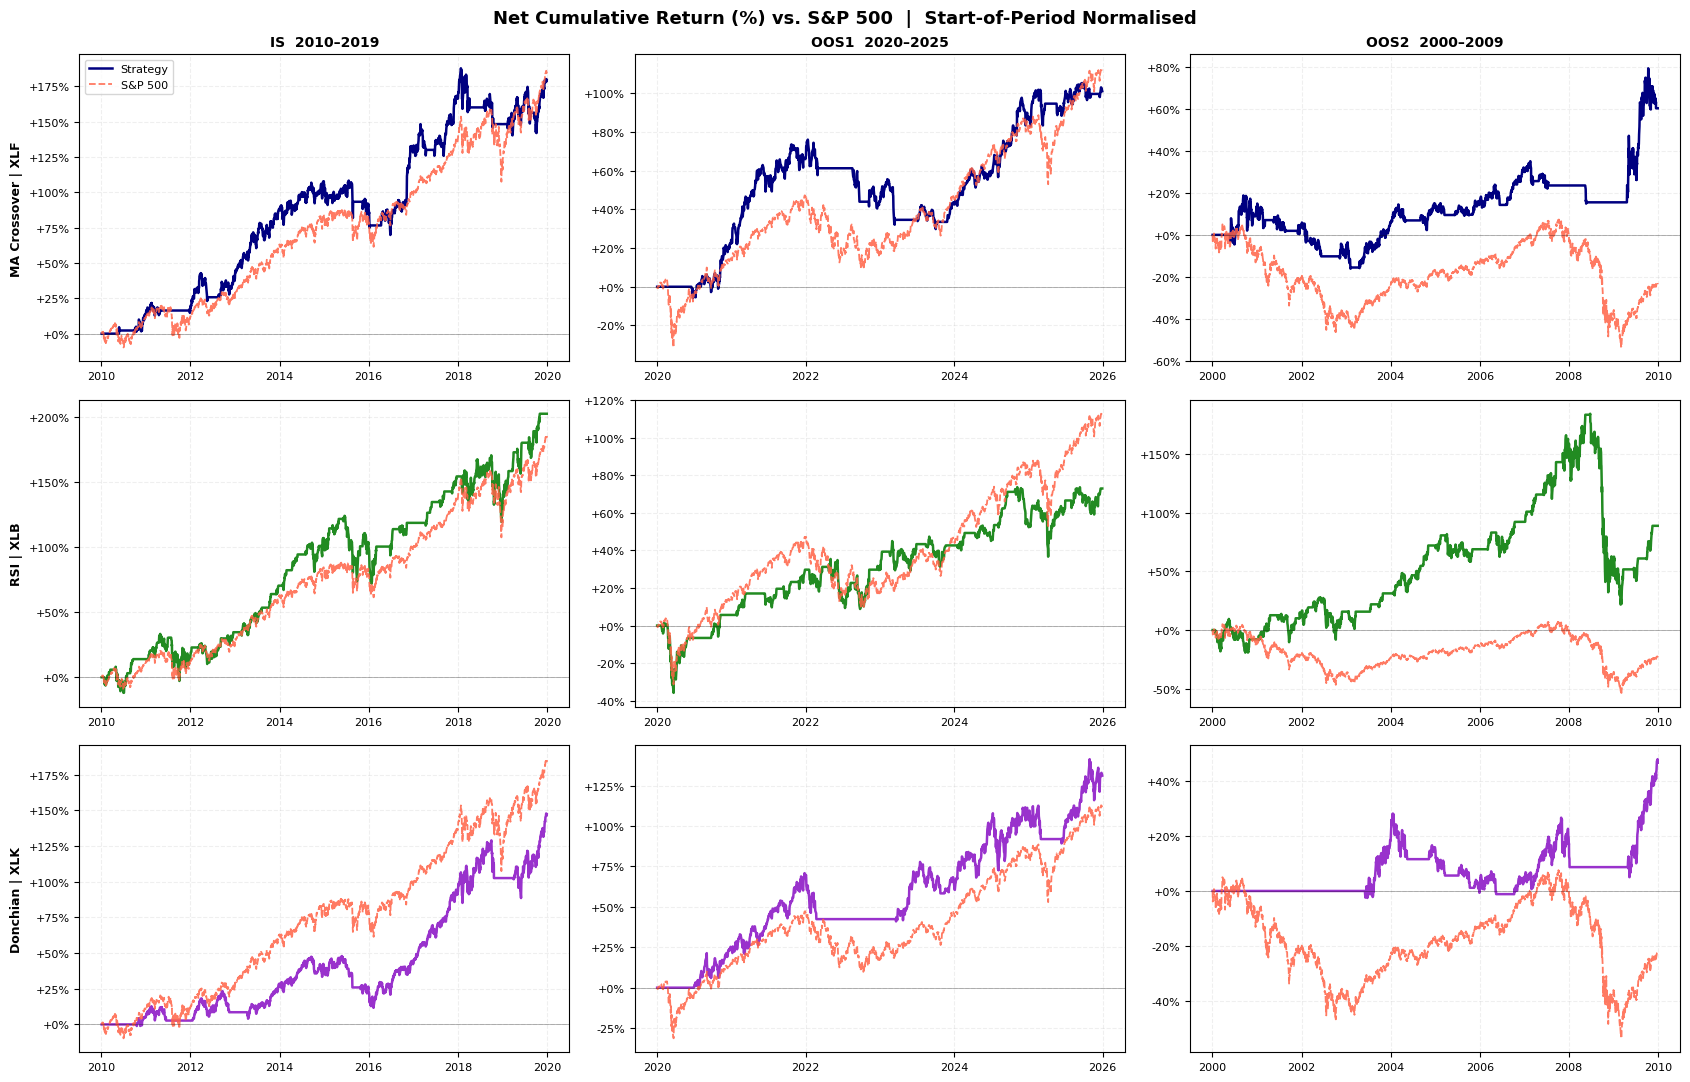

In [39]:
signal_rows = [
    ('MA Crossover | XLF',  pv_ma_is,  pv_ma_oos1,  pv_ma_oos2,
     df_finance_is,    df_finance_oos1,    df_finance_oos2,    'navy'),
    ('RSI | XLB',           pv_rsi_is, pv_rsi_oos1, pv_rsi_oos2,
     df_materials_is,  df_materials_oos1,  df_materials_oos2,  'forestgreen'),
    ('Donchian | XLK',      pv_don_is, pv_don_oos1, pv_don_oos2,
     df_technology_is, df_technology_oos1, df_technology_oos2, 'darkorchid'),
]
period_titles = ['IS  2010–2019', 'OOS1  2020–2025', 'OOS2  2000–2009']

fig, axes = plt.subplots(3, 3, figsize=(17, 11))
fig.suptitle(
    'Net Cumulative Return (%) vs. S&P 500  |  Start-of-Period Normalised',
    fontsize=13, fontweight='bold'
)

for r, (sig_label, pv_is_, pv_oos1_, pv_oos2_,
        df_is_, df_oos1_, df_oos2_, color) in enumerate(signal_rows):

    for c, (pv_, df_, period_label) in enumerate([
        (pv_is_,   df_is_,   period_titles[0]),
        (pv_oos1_, df_oos1_, period_titles[1]),
        (pv_oos2_, df_oos2_, period_titles[2]),
    ]):
        ax = axes[r][c]
        dates = df_.index.to_numpy()
        spx_ref = spx_is if c == 0 else (spx_oos1 if c == 1 else spx_oos2)
        spx_v = module.spx_normalise(df_, spx_ref)

        net_strat = (pv_ / pv_[0] - 1) * 100
        net_spx   = (spx_v / spx_v[0] - 1) * 100

        ax.plot(dates, net_strat, color=color, lw=1.8, label='Strategy')
        ax.plot(dates, net_spx,   color='tomato', lw=1.3,
                linestyle='--', alpha=0.85, label='S&P 500')
        ax.axhline(0, color='black', lw=0.5, alpha=0.4)

        if r == 0:
            ax.set_title(period_label, fontsize=10, fontweight='bold')
        if c == 0:
            ax.set_ylabel(sig_label, fontsize=9, fontweight='bold')

        ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:+.0f}%'))
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
        ax.xaxis.set_major_locator(mdates.YearLocator(2))
        ax.tick_params(axis='x', labelsize=8)
        ax.tick_params(axis='y', labelsize=8)
        ax.grid(True, which='both', alpha=0.2, linestyle='--')
        if r == 0 and c == 0:
            ax.legend(fontsize=8, loc='upper left')

plt.tight_layout()
plt.show()

---
## 7. Drawdown Curves 

Shaded area shows the strategy underwater period; dashed red is the S&P 500 drawdown.

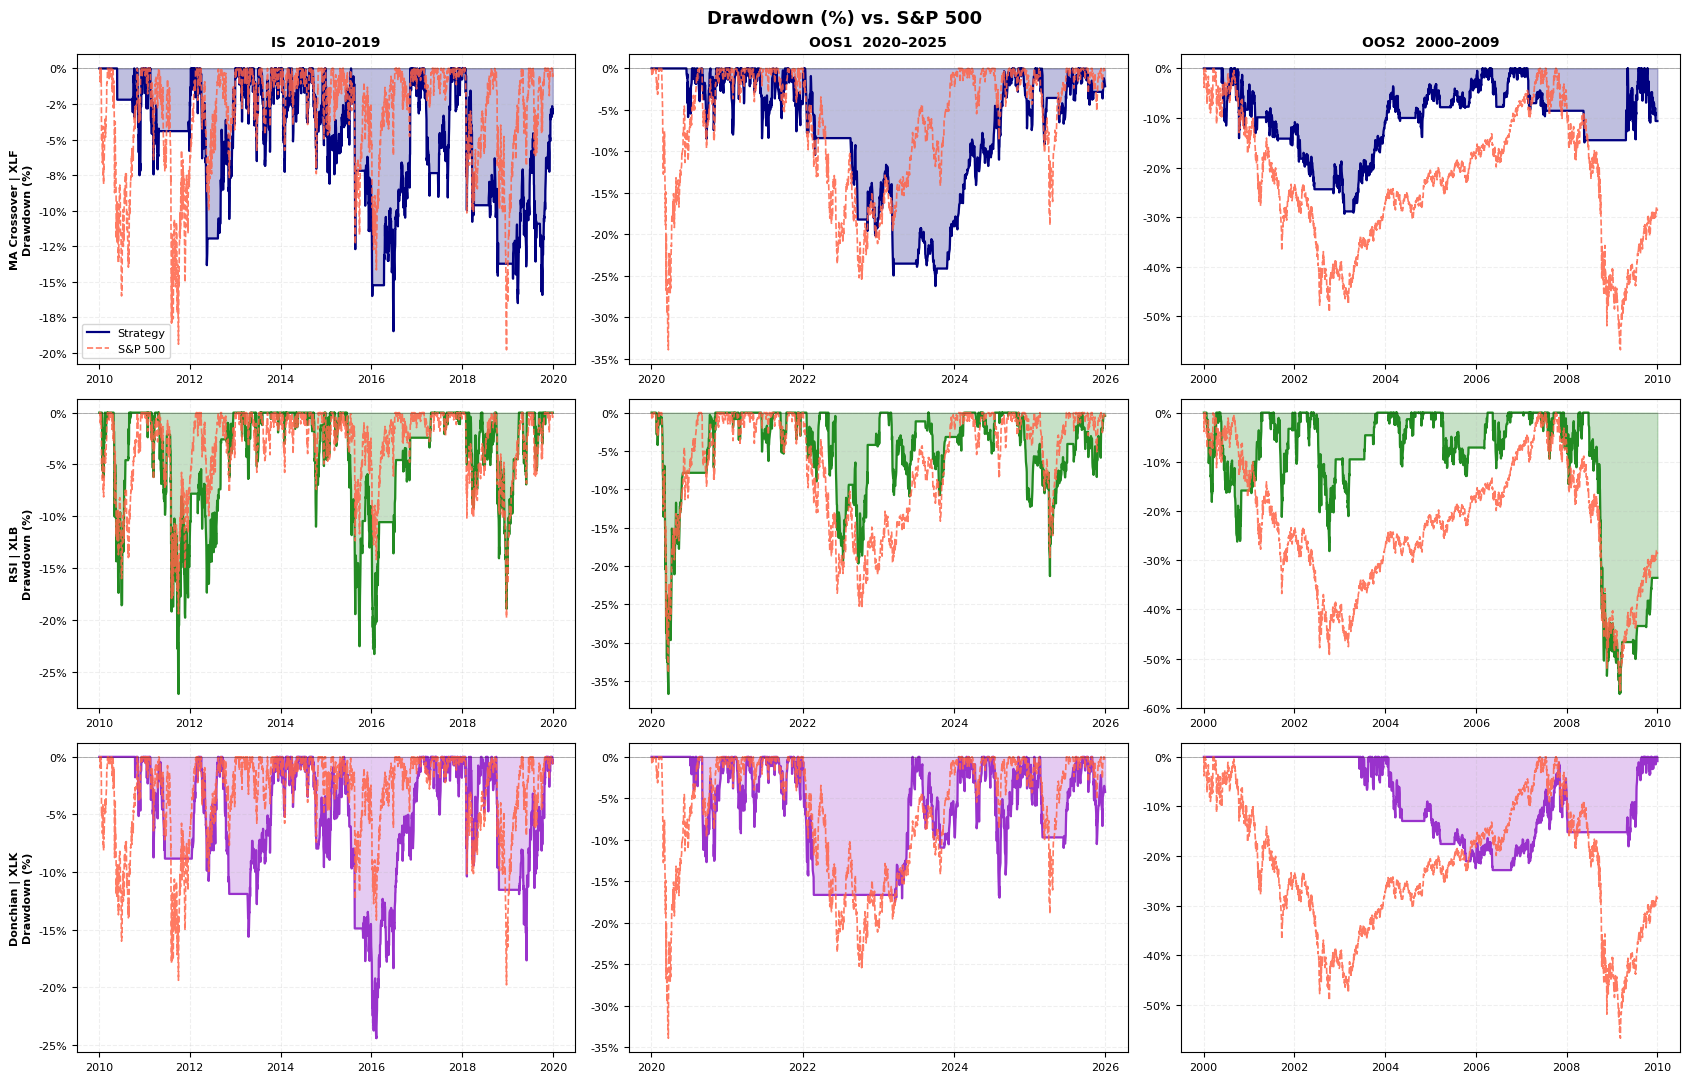

In [40]:
fig_dd, axes_dd = plt.subplots(3, 3, figsize=(17, 11))
fig_dd.suptitle(
    'Drawdown (%) vs. S&P 500',
    fontsize=13, fontweight='bold'
)

for r, (sig_label, pv_is_, pv_oos1_, pv_oos2_,
        df_is_, df_oos1_, df_oos2_, color) in enumerate(signal_rows):

    for c, (pv_, df_, period_label) in enumerate([
        (pv_is_,   df_is_,   'IS  2010–2019'),
        (pv_oos1_, df_oos1_, 'OOS1  2020–2025'),
        (pv_oos2_, df_oos2_, 'OOS2  2000–2009'),
    ]):
        ax = axes_dd[r][c]
        dates = df_.index.to_numpy()
        spx_ref = spx_is if c == 0 else (spx_oos1 if c == 1 else spx_oos2)
        spx_v = module.spx_normalise(df_, spx_ref)

        dd_strat = module.compute_dd(pv_)
        dd_spx   = module.compute_dd(spx_v)

        ax.fill_between(dates, dd_strat, 0, alpha=0.25, color=color)
        ax.plot(dates, dd_strat, color=color, lw=1.6, label='Strategy')
        ax.plot(dates, dd_spx,   color='tomato', lw=1.2,
                linestyle='--', alpha=0.85, label='S&P 500')
        ax.axhline(0, color='black', lw=0.5, alpha=0.4)

        if r == 0:
            ax.set_title(period_label, fontsize=10, fontweight='bold')
        if c == 0:
            ax.set_ylabel(sig_label + '\nDrawdown (%)', fontsize=8, fontweight='bold')

        ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}%'))
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
        ax.xaxis.set_major_locator(mdates.YearLocator(2))
        ax.tick_params(axis='x', labelsize=8)
        ax.tick_params(axis='y', labelsize=8)
        ax.grid(True, which='both', alpha=0.2, linestyle='--')
        if r == 0 and c == 0:
            ax.legend(fontsize=8, loc='lower left')

plt.tight_layout()
plt.show()

---
## 8. Conclusion & Final Parameter Justification

**1. Setup** includes libraries, ETFs and evaluation periods.

**2. Signal Catalogue** establishes that MA Crossover, RSI, and Donchian are structurally distinct (trend-following, mean reversion, price-channel breakout), ensuring uncorrelated exposures across the three strategies.

**3. ETF assignment** was driven by IS Sortino across all 70 signal–ETF pairs: MA Cross–XLF (IS 1.22), RSI–XLB (IS 1.03), and Donchian–XLK (IS 1.07) were chosen on in-sample fit, not OOS performance. ETFs eliminate single-stock idiosyncratic risk.

**4. IS parameter optimisation** used Sortino-ratio grid search on 2010–2019 data only, with parameters frozen before any OOS data was examined. The Deflated Sharpe Ratio returns 100% for all three strategies (MA: 24 combinations, RSI: 35, Donchian: 24), confirming genuine skill rather than overfitting.

**5. Walk-forward Validation Performance Table** reports Sortino, Sharpe, CAGR, maximum drawdown, and Calmar ratio for each strategy across all three evaluation windows, benchmarked against the S&P 500. It provides the primary evidence on whether IS performance generalises to unseen data.

**6. Net Cumulative Return Curves** & **7. Drawdown Curves** are presented for all three signals across all three evaluation periods.


**References:**
- Pardo, R. (2008). *The Evaluation and Optimization of Trading Strategies* (2nd ed.). Wiley Trading.
- Sharpe, W. F. (1994). *The Sharpe Ratio.* JPM, 21(1), 49-58.
- Wilder, J. W. (1978). *New Concepts in Technical Trading Systems.* Trend Research.
- Sortino, F. A., & van der Meer, R. (1991). *Downside Risk.* JPM, 17(4), 27-31.
- Donchian, R. D. (1960). *High Finance in Copper.* Financial Analysts Journal.
- Covel, M. (2007). *The Complete TurtleTrader.* HarperCollins.
- De Bondt, W., & Thaler, R. (1985). *Does the Stock Market Overreact?* JF, 40(3).
- Shleifer, A., & Vishny, R. W. (1997). *The Limits of Arbitrage.* JF, 52(1), 35-55.
- McLean, R. D., & Pontiff, J. (2016). *Does Publishing Research Destroy Stock Return Predictability?* JF, 71(1).
- Bailey, D. H., & López de Prado, M. (2014). *The Deflated Sharpe Ratio.* JPM, 40(5).
- Elton, E. J., & Gruber, M. J. (1997). *Modern Portfolio Theory and Investment Analysis.* Wiley.
- Korajczyk, R. A., & Sadka, R. (2004). *Are Momentum Profits Robust to Trading Costs?* JF, 59(3).